# Credit Risk Modelling Project

## Project Introduction
Credit risk modelling is a key component of lending decisions in financial institutions. Lenders must evaluate whether a borrower is likely to repay a loan or default.

This project develops a simple credit risk model using Lending Club loan data. The objective is to predict borrower default using financial and loan-related characteristics. A logistic regression model is implemented to estimate the probability of default, and these probabilities are subsequently transformed into a simplified credit scoring system.

The project demonstrates a typical credit risk modelling pipeline including data preparation, feature engineering, model training, evaluation, and scorecard construction.

In [2]:
# import modules
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Dataset Description
The dataset used in this project is derived from Lending Club loan data, which contains information on borrower financial characteristics and loan attributes.

The sample used in this analysis contains approximately 20,000 observations and includes variables such as loan amount, interest rate, employment length, annual income, debt-to-income ratio, and credit grade.

The target variable is loan status, which indicates whether a borrower repaid the loan or defaulted. This variable is converted into a binary default indicator used for modelling.

Link to full dataset is available [here.](https://www.kaggle.com/datasets/marcusos/lending-club-clean?resource=download)

## Data Preparation

Prior to modelling, several preprocessing steps were applied to ensure the dataset was suitable for machine learning.

These steps included:

- Handling missing values in selected variables

- Converting categorical variables into numerical representations

- Creating a binary default indicator based on loan status

- Standardising numerical variables for model stability

These transformations allow the logistic regression model to process the data effectively.

In [3]:
# import dataset
df = pd.read_csv('lending_club_clean.csv', low_memory=False)
df = df[df["loan_status"].isin(["Fully Paid", "Charged Off"])]

In [4]:
# select sample and relevant columns
df_sample = df.sample(n=20000, random_state=42)
columns_to_keep = [
    'loan_amnt',
    'term',
    'int_rate',
    'installment', 
    'grade',
    'emp_length',
    'home_ownership',
    'annual_inc',
    'loan_status',
    'purpose',
    'dti',
    'delinq_2yrs',
    'revol_util',
    'total_acc']
df_sample = df_sample[columns_to_keep]
df_sample.to_csv('lending_club_20ksample.csv', index=False)
df = pd.read_csv('lending_club_20ksample.csv')

In [5]:
# fixing null data 
df['revol_util'] = df['revol_util'].fillna(df['revol_util'].median())
df['emp_length'] = df['emp_length'].fillna('Unknown')

In [6]:
# creating binary default variable
df['loan_status'].value_counts()
df['default'] = df['loan_status'].apply(
    lambda x: 1 if x in ['Charged Off'] else 0
)
df = df.drop('loan_status', axis=1)

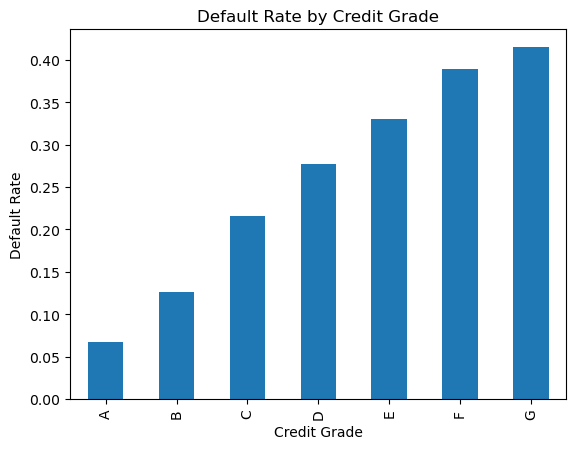

In [7]:
# illustrating default rate by grade
df.groupby('grade')['default'].mean().plot(kind='bar')

plt.title('Default Rate by Credit Grade')
plt.ylabel('Default Rate')
plt.xlabel('Credit Grade')

plt.show()

The chart above shows a clear and consistent increase in default rates across Lending Club's credit grades, rising from approximately 5% for Grade A borrowers to over 30% for Grade G. This monotonic relationship confirms that the grade variable is a strong indicator of credit risk with each step down the grading scale corresponding to a meaningfully higher likelihood of default.

Notably, the rate of increase accelerates in the lower grades (E through G), suggesting that risk is not distributed evenly across the spectrum but instead concentrates sharply at the tail. This pattern supports the decision to include grade as a key feature in the logistic regression model.

## Logistic Regression Model

Logistic regression is widely used in credit risk modelling because it estimates the probability that a borrower will default.
The model predicts the likelihood of default based on borrower financial characteristics and loan attributes.

The dataset was split into training and testing sets, allowing the model to be trained on one portion of the data and evaluated on unseen observations.

In [8]:
# converting catagorical variables into integers
df = pd.get_dummies(df, columns=[
    'grade',
    'home_ownership',
    'purpose'
], drop_first=True)
bool_cols = df.select_dtypes(include=bool).columns
df[bool_cols] = df[bool_cols].astype(int)

df['emp_length'] = df['emp_length'].replace({'Unknown': '0', '< 1 year': '0', '1 year': '1', '2 years': '2', '3 years': '3', '4 years': '4', '5 years': '5', '6 years': '6', '7 years': '7', '8 years': '8', '9 years': '9', '10+ years': '10'})
df['emp_length'] = df['emp_length'].replace(df['emp_length']).astype(int)

In [9]:
# split data
from sklearn.model_selection import train_test_split

X = df.drop('default', axis=1)
y = df['default']

X_train, X_test, y_train, y_test = train_test_split( 
    X, y,
    test_size=0.2,
    random_state=42
)

In [10]:
# scaling variables
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [11]:
# training model 
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train_scaled, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [12]:
# predictions
predictions = model.predict(X_test_scaled)

In [13]:
# checking model accuracy
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, predictions)
print(accuracy)

0.81875


## Model Evaluation

The model was evaluated on a held-out test set of 4,000 observations — 20% of the full sample — that was not used during training. Three evaluation methods were used: a confusion matrix, a classification report, and the ROC AUC score.

In [14]:
# checking model's confusion matrix
from sklearn.metrics import confusion_matrix

print(confusion_matrix(y_test, predictions))

[[3259   15]
 [ 710   16]]


A confusion matrix breaks down predictions into four categories: true positives (defaults correctly identified), true negatives (repayments correctly identified), false positives (repayments incorrectly flagged as defaults), and false negatives (defaults incorrectly classified as repayments).

The results show that the model correctly classified 3,259 out of 3,274 non-defaulting borrowers, but identified only 16 out of 726 actual defaults — a recall rate of just 2.2% for the default class. This reveals a significant weakness: the model is heavily biased towards predicting repayment, largely because non-defaulters make up roughly 82% of the test set. In a real lending context, missing this many defaults would be a material risk management concern.

In [15]:
# classification report
from sklearn.metrics import classification_report

print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

           0       0.82      1.00      0.90      3274
           1       0.52      0.02      0.04       726

    accuracy                           0.82      4000
   macro avg       0.67      0.51      0.47      4000
weighted avg       0.77      0.82      0.74      4000



In [16]:
# predicting default probabilities
prob = model.predict_proba(X_test_scaled)
default_prob = prob[:,1]

0.6931185010543038


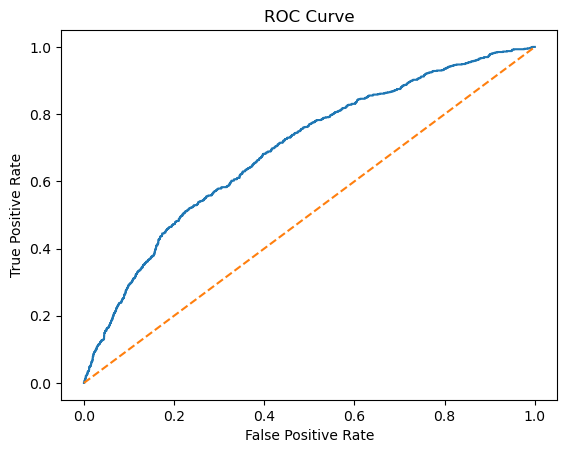

In [17]:
# ROC AUC 
from sklearn.metrics import roc_auc_score

print(roc_auc_score(y_test, default_prob))

# ROC curve
from sklearn.metrics import roc_curve
fpr, tpr, thresholds = roc_curve(y_test, default_prob)

plt.plot(fpr, tpr)
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
    
plt.show()

The ROC (Receiver Operating Characteristic) curve plots the true positive rate against the false positive rate at every possible classification threshold, giving a threshold-independent view of the model's discriminatory ability. The AUC (Area Under the Curve) summarises this into a single score between 0.5 (random guessing) and 1.0 (perfect discrimination).

The model achieved an AUC of **0.6931**, indicating moderate discriminatory power. While the model performs better than chance, this falls below the 0.75 threshold commonly expected in industry credit models. This is consistent with the limitations of logistic regression on a relatively small feature set — the model captures meaningful signal from variables like interest rate and grade, but lacks the complexity to fully separate defaulters from non-defaulters. This result motivates exploring more advanced approaches such as gradient boosting in future iterations.

## Credit Scoring System

The predicted probabilities of default were transformed into a simplified credit scoring system ranging from 300 to 850, where higher scores indicate lower predicted default risk.

Borrowers were also grouped into risk bands (Low, Medium, and High risk) based on their credit scores.

This approach illustrates how probability-based credit risk models can be converted into practical decision-making tools used in lending institutions.

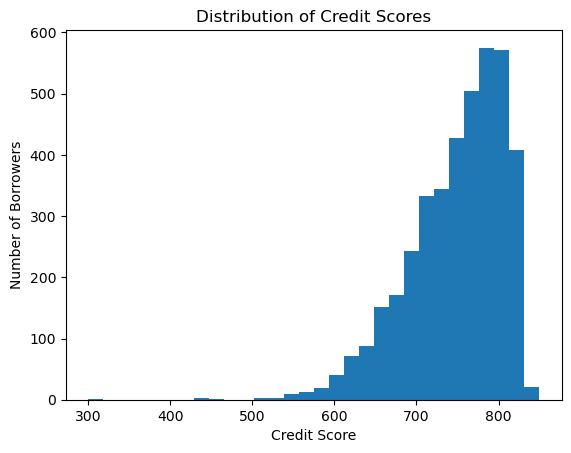

In [18]:
# creating a credit scorer 
credit_score = 850 - (default_prob * 550)

results = pd.DataFrame({
    'Actual_Default': y_test,
    'Predicted_Default': predictions,
    'Default_Probability': default_prob,
    'Credit_Score': credit_score
})

def risk_band(score):
    if score > 750:
        return 'Low Risk'
    elif score > 650:
        return 'Medium Risk'
    else:
        return 'High Risk'

results['Risk_Band'] = results['Credit_Score'].apply(risk_band)

plt.hist(results['Credit_Score'], bins=30)
plt.title('Distribution of Credit Scores')
plt.xlabel('Credit Score')
plt.ylabel('Number of Borrowers')
plt.show()

The histogram above shows the distribution of predicted credit scores across the 4,000 test borrowers. Scores are calculated using the formula `850 − (default_probability × 550)`, mapping predicted default probabilities onto a 300 – 850 scale consistent with standard credit scoring conventions.

The distribution is right-skewed, with the majority of borrowers concentrated between 750 and 820 which corresponds to predicted default probabilities of roughly 5–18%. Very few borrowers score below 650 (implied default probability above 36%), reflecting the class imbalance in the underlying data where non-defaulters significantly outnumber defaulters. This skew is expected behaviour given the sample composition, but would need to be monitored carefully in production to avoid systematically under-pricing risk for borderline borrowers.

## Key Risk Drivers

Several borrower characteristics appear to influence default risk within the dataset. Variables such as higher debt-to-income ratios, weaker credit grades, and higher interest rates tend to be associated with increased default probabilities.

These findings are consistent with standard credit risk theory, where borrowers with weaker financial profiles typically exhibit higher credit risk.

In [19]:
# extracting risk factors
coefficients = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': model.coef_[0]
})

coefficients.sort_values(by='Coefficient', ascending=False)

,Feature,Coefficient
2,int_rate,0.335785
11,grade_C,0.264481
12,grade_D,0.217274
1,term,0.204188
10,grade_B,0.143383
6,dti,0.137359
13,grade_E,0.116198
3,installment,0.107646
24,purpose_home_improvement,0.057668
14,grade_F,0.057206


The model coefficients indicate which borrower characteristics are associated with higher default risk. Positive coefficients increase the predicted probability of default, while negative coefficients reduce it. The table above shows that variables such as higher interest rates, weaker credit grades, and higher debt-to-income ratios do appear to increase borrower risk.

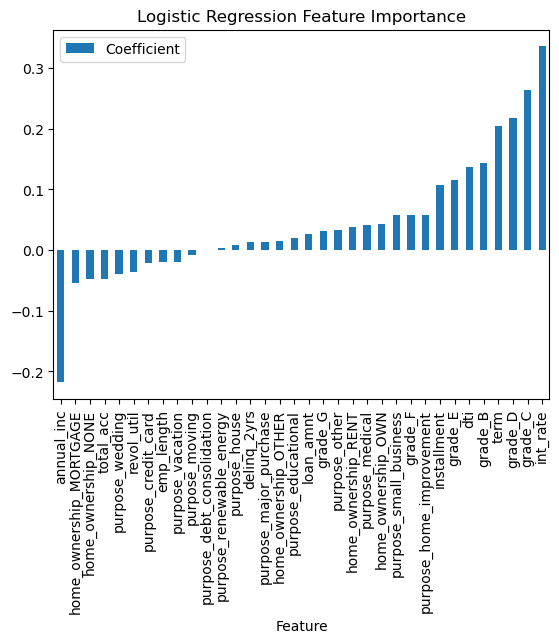

In [20]:
# illustrating feature importance
coefficients.sort_values('Coefficient').plot(
    x='Feature',
    y='Coefficient',
    kind='bar'
)

plt.title('Logistic Regression Feature Importance')

plt.show()

The logistic regression coefficients indicate that variables such as higher interest rates, weaker credit grades, and longer loan terms are associated with increased default risk, while higher income and home ownership appear to reduce risk.

## Limitations 

This project presents a simplified credit risk modelling framework and therefore has several limitations, including but not limited to:

- The dataset was sampled and may not represent the full Lending Club portfolio.

- Logistic regression captures only linear relationships between variables and default risk.

- Additional borrower characteristics, behavioural variables, and macroeconomic factors that were not included could improve predictive performance.

Future work could involve testing more advanced models such as random forests or gradient boosting techniques.

## Conclusion

This project demonstrates how machine learning techniques can be applied to model credit risk using borrower financial data.

A logistic regression model was implemented to estimate default probabilities and translated into a simplified credit scoring system. While the model has moderate predictive power, it highlights the key steps involved in building a practical credit risk model used in financial institutions.